# 1. imports and environment setup

In [1]:
import os
import glob
import pandas as pd
import numpy as np

# 1. Network Path for NWB files (using raw string r"...")
DATA_DIR = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types"

# 2. Local directory for saving extracted results
RESULTS_DIR = r"../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 3. Google Sheet Metadata Export URL (converted to CSV format)
SHEET_ID = "1CpN3jsWR5c84a57sGSgWtrgvnnLRKjxJgxjQg8Alx1I"
GID = "1820785849"
METADATA_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

print("Paths configured.")

Paths configured.


## 1a. load metadata sheet directly from GSheet

In [3]:
from datetime import datetime

# Download and load metadata spreadsheet directly into pandas
try:
    metadata_df = pd.read_csv(METADATA_URL)
    print(f"Successfully loaded metadata sheet with {len(metadata_df)} rows.")
    
    # Generate timestamp and set filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = f"2025_STR_MSN_analysis_{timestamp}.csv"
    
    # Save a local backup copy in analysis/data/metadata
    os.makedirs("../data/metadata", exist_ok=True)
    save_path = os.path.join("../data/metadata", filename)
    
    metadata_df.to_csv(save_path, index=False)
    print(f"Saved metadata backup to: {save_path}")
    
    display(metadata_df.head())
except Exception as e:
    print(f"Error downloading Google Sheet: {e}")

Successfully loaded metadata sheet with 198 rows.
Saved metadata backup to: ../data/metadata\2025_STR_MSN_analysis_20260930_124309.csv


,date,cell_name,file_path,virus,cell_type_targeted,reclassified_cell_type,fluorescent_label,cell_access(mOhms),holding_current(pA),v_rest(mV),physiology,morphology_alexa_fill,ROI,hemisphere_location,tube_id,20Xlims_link
0,250527,C57BL6J-803061.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,NaN,NaN,-75.0,NaN,NaN,NaN,NaN,NaN,NaN
1,250527,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,NaN,NaN,-75.5,NaN,NaN,NaN,NaN,NaN,NaN
2,250603,C57BL6J-795017.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,NaN,NaN,-74.5,NaN,NaN,NaN,NaN,NaN,NaN
3,250603,C57BL6J-795017.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,NaN,NaN,-65.0,NaN,NaN,NaN,NaN,NaN,NaN
4,250603,C57BL6J-795017.01.03,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,NaN,NaN,-62.5,NaN,NaN,NaN,NaN,NaN,NaN


## 1b. verify access to nwb files in Allen network folder

In [4]:
# Check for .nwb files in the network directory
nwb_files = glob.glob(os.path.join(DATA_DIR, "*.nwb"))

print(f"Found {len(nwb_files)} .nwb files in the network folder.")

if nwb_files:
    print("Sample file found:", os.path.basename(nwb_files[0]))
else:
    print("Warning: No .nwb files found. Verify network connection or folder permissions.")

Found 219 .nwb files in the network folder.
Sample file found: 2025_05_27_125926_cell5_minis_FIcurve-compressed.nwb


# 2. run ifpx feature extraction on network files

universal NWB loader function

In [20]:
import os
import glob
import h5py
import pandas as pd
import numpy as np

# Core IPFX imports
from ipfx.dataset.create import create_ephys_data_set
from ipfx.data_set_features import extract_data_set_features
from ipfx.feature_extractor import SpikeFeatureExtractor


def inspect_nwb_version(file_path):
    """Detects whether an NWB file is version 1.0 or 2.0."""
    try:
        with h5py.File(file_path, 'r') as f:
            if "nwb_version" in f.attrs:
                ver = f.attrs["nwb_version"]
                return str(ver.decode('utf-8') if isinstance(ver, bytes) else ver)
            elif "nwb_version" in f:
                ver = f["nwb_version"][()]
                return str(ver.decode('utf-8') if isinstance(ver, bytes) else ver)
    except Exception:
        pass
    return "1.0"


def extract_features_nwb2(file_path):
    """Processes NWB 2.0 files using standard IPFX dataset features."""
    data_set = create_ephys_data_set(nwb_file=file_path)
    cell_features, _ = extract_data_set_features(data_set)
    
    hero = cell_features.get('hero_sweep', {})
    
    return {
        "v_rest_mv": cell_features.get("v_baseline", np.nan),
        "r_in_mOhm": cell_features.get("input_resistance", np.nan),
        "sag_fraction": cell_features.get("sag", np.nan),
        "rheobase_pa": hero.get("stim_amp", np.nan) if hero else np.nan,
        "ap_peak_mv": hero.get("peak_v", np.nan) if hero else np.nan,
        "ap_half_width_ms": hero.get("width", np.nan) * 1000.0 if hero else np.nan
    }


def extract_features_nwb1_h5py(file_path):
    """Reads NWB 1.0 files directly via h5py and extracts features using IPFX SpikeFeatureExtractor."""
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else {}
        
        sweep_keys = [k for k in acq.keys() if k.startswith("data_") and k.endswith("_AD0")]
        
        baselines = []
        r_in_list = []
        sag_list = []
        
        lowest_rheo_i = np.inf
        hero_spikes_df = None
        hero_stim_amp = np.nan
        
        for skey in sweep_keys:
            sweep_num = skey.split("_")[1]
            v = acq[skey]['data'][:]
            
            # Convert V to mV
            if np.max(np.abs(v)) < 1.0:
                v *= 1000.0
                
            # Retrieve injected current (DA0)
            ikey = f"data_{sweep_num}_DA0"
            if ikey in stim:
                i = stim[ikey]['data'][:]
                if np.max(np.abs(i)) < 1e-3:
                    i *= 1e12  # Convert Amperes to pA
            else:
                i = np.zeros_like(v)
                
            # Time vector in seconds
            if 'timestamps' in acq[skey]:
                t = acq[skey]['timestamps'][:]
            else:
                t = np.arange(len(v)) / 25000.0
                
            # Calculate baseline voltage (pre-stimulus period)
            base_idx = int(0.1 * 25000) if len(v) > 2500 else 100
            v_base = np.mean(v[:base_idx])
            baselines.append(v_base)
            
            # Stimulus step analysis
            i_step = np.mean(i[base_idx:base_idx+1000]) if len(i) > base_idx+1000 else 0
            delta_i = np.max(i) - i_step if np.max(i) > 0 else np.min(i) - i_step
            
            # Hyperpolarizing sweeps -> Input Resistance & Sag
            if delta_i < -5.0:
                v_steady = np.mean(v[-1000:])
                v_trough = np.min(v)
                delta_v = v_steady - v_base
                
                if abs(delta_i) > 0:
                    r_in = (delta_v / delta_i) * 1000.0  # MOhms
                    if 0 < r_in < 1500:
                        r_in_list.append(r_in)
                        
                if abs(v_trough - v_base) > 0:
                    sag = (v_trough - v_steady) / (v_trough - v_base)
                    if 0 <= sag <= 1.0:
                        sag_list.append(sag)
                        
            # Spiking sweeps -> Action Potential metrics via IPFX
            if np.max(v) > 0.0 and delta_i > 0:
                try:
                    spikes = spike_extractor.process(t, v, i)
                    if len(spikes) > 0 and delta_i < lowest_rheo_i:
                        lowest_rheo_i = delta_i
                        hero_stim_amp = delta_i
                        hero_spikes_df = spikes
                except Exception:
                    pass

        # Aggregate cell features
        v_rest_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        sag_final = np.median(sag_list) if sag_list else np.nan
        
        ap_peak = np.nan
        ap_hw = np.nan
        
        if hero_spikes_df is not None and not hero_spikes_df.empty:
            first_spike = hero_spikes_df.iloc[0]
            ap_peak = first_spike.get('peak_v', np.nan)
            ap_hw = first_spike.get('width', np.nan) * 1000.0  # Convert sec to ms

        return {
            "v_rest_mv": v_rest_final,
            "r_in_mOhm": r_in_final,
            "sag_fraction": sag_final,
            "rheobase_pa": hero_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "ap_peak_mv": ap_peak,
            "ap_half_width_ms": ap_hw
        }


def process_all_nwb_files(nwb_file_list):
    """Loops through all files, routes them by version, and extracts features."""
    extracted_rows = []
    
    for nwb_path in nwb_file_list:
        cell_id = os.path.basename(nwb_path).replace(".nwb", "")
        version_str = inspect_nwb_version(nwb_path)
        
        try:
            if version_str.startswith("2") or "2." in version_str:
                # NWB 2.0 path
                features = extract_features_nwb2(nwb_path)
                features["nwb_version"] = "2.0"
            else:
                # NWB 1.0 h5py path
                features = extract_features_nwb1_h5py(nwb_path)
                features["nwb_version"] = "1.0"
                
            features["cell_id"] = cell_id
            extracted_rows.append(features)
            print(f"✅ Processed {cell_id} (NWB {features['nwb_version']})")
            
        except Exception as e:
            print(f"❌ Error processing {cell_id}: {e}")

    df_features = pd.DataFrame(extracted_rows)
    
    # Save results to CSV
    os.makedirs("../results", exist_ok=True)
    out_path = "../results/all_cells_ephys_features.csv"
    df_features.to_csv(out_path, index=False)
    
    print(f"\n🎉 Extraction Complete! Saved features for {len(df_features)} cells to: {out_path}")
    return df_features

test single cell extraction (NWB 1.0 or 2.0)

In [21]:
if nwb_files:
    # 1. Pick the first cell file in your list
    sample_file = nwb_files[0]
    cell_id = os.path.basename(sample_file).replace(".nwb", "")
    
    # 2. Check NWB version
    version_str = inspect_nwb_version(sample_file)
    print(f"🔍 Testing Single Cell: {cell_id}")
    print(f"📦 NWB Version Detected: {version_str}\n")
    
    # 3. Route and extract features
    try:
        if version_str.startswith("2") or "2." in version_str:
            features = extract_features_nwb2(sample_file)
            features["nwb_version"] = "2.0"
        else:
            features = extract_features_nwb1_h5py(sample_file)
            features["nwb_version"] = "1.0"
            
        features["cell_id"] = cell_id
        
        # 4. Display extracted metrics as a clean DataFrame
        df_single = pd.DataFrame([features])
        display(df_single)
        
    except Exception as e:
        print(f"❌ Error processing {cell_id}: {e}")
else:
    print("⚠️ No .nwb files found in DATA_DIR.")

🔍 Testing Single Cell: 2025_05_27_125926_cell5_minis_FIcurve-compressed
📦 NWB Version Detected: [b'NWB-1.0.5']



,v_rest_mv,r_in_mOhm,sag_fraction,rheobase_pa,ap_peak_mv,ap_half_width_ms,nwb_version,cell_id
0,-22.065039,NaN,NaN,10.0,443.75,1.2,1.0,2025_05_27_125926_cell5_minis_FIcurve-compressed


single cell test script

In [22]:
import os
import glob
import h5py
import pandas as pd
import numpy as np

# Core IPFX imports
from ipfx.dataset.create import create_ephys_data_set
from ipfx.data_set_features import extract_data_set_features
from ipfx.feature_extractor import SpikeFeatureExtractor


def get_cell_name_from_metadata(file_path, metadata_df):
    """Matches NWB file path/name with official cell_name in Google Sheet metadata."""
    file_basename = os.path.basename(file_path).lower()
    if 'file_path' in metadata_df.columns and 'cell_name' in metadata_df.columns:
        for _, row in metadata_df.iterrows():
            if pd.notna(row['file_path']):
                meta_basename = os.path.basename(str(row['file_path'])).lower()
                if file_basename == meta_basename:
                    return str(row['cell_name']).strip()
    return os.path.splitext(file_basename)[0]


def extract_features_nwb1_h5py(file_path):
    """Reads NWB 1.0 files directly via h5py and extracts ephys features."""
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else {}
        
        sweep_keys = [k for k in acq.keys() if k.startswith("data_") and k.endswith("_AD0")]
        
        baselines = []
        r_in_list = []
        sag_list = []
        
        lowest_rheo_i = np.inf
        hero_spikes_df = None
        hero_stim_amp = np.nan
        
        for skey in sweep_keys:
            sweep_num = skey.split("_")[1]
            v = acq[skey]['data'][:]
            
            # Correct Voltage scaling (V to mV)
            if np.max(np.abs(v)) < 0.2:
                v = v * 1000.0
            elif np.max(np.abs(v)) > 200.0:
                v = v / 10.0  # Adjust for 10x gain factor if present
                
            # Retrieve injected current (DA0)
            ikey = f"data_{sweep_num}_DA0"
            if ikey in stim:
                i = stim[ikey]['data'][:]
                if np.max(np.abs(i)) < 1e-3:
                    i = i * 1e12  # Convert Amperes to pA
            else:
                i = np.zeros_like(v)
                
            # Time vector in seconds
            if 'timestamps' in acq[skey]:
                t = acq[skey]['timestamps'][:]
                if np.max(t) > 1000:
                    t = t / 1000.0  # Convert ms to sec
            else:
                t = np.arange(len(v)) / 25000.0
                
            # Baseline Vm
            base_idx = int(0.1 * 25000) if len(v) > 2500 else 100
            v_base = np.mean(v[:base_idx])
            baselines.append(v_base)
            
            # Calculate current step amplitude
            non_zero_i = np.where(np.abs(i) > 2.0)[0]
            i_step = np.mean(i[non_zero_i]) if len(non_zero_i) > 0 else 0.0
            
            # Hyperpolarizing sweeps (Negative current steps) -> Input Resistance & Sag
            if i_step < -5.0:
                v_steady = np.mean(v[-1000:])
                v_trough = np.min(v)
                delta_v = v_steady - v_base
                
                if abs(i_step) > 0:
                    r_in = (delta_v / i_step) * 1000.0  # MOhms
                    if 0 < r_in < 2000:
                        r_in_list.append(r_in)
                        
                if abs(v_trough - v_base) > 0:
                    sag = (v_trough - v_steady) / (v_trough - v_base)
                    if 0 <= sag <= 1.0:
                        sag_list.append(sag)
                        
            # Spiking sweeps (Positive current steps) -> Action Potential metrics
            if np.max(v) > -10.0 and i_step > 0:
                try:
                    spikes = spike_extractor.process(t, v, i)
                    if len(spikes) > 0 and i_step < lowest_rheo_i:
                        lowest_rheo_i = i_step
                        hero_stim_amp = i_step
                        hero_spikes_df = spikes
                except Exception:
                    pass

        return {
            "v_rest_mv": np.mean(baselines) if baselines else np.nan,
            "r_in_mOhm": np.median(r_in_list) if r_in_list else np.nan,
            "sag_fraction": np.median(sag_list) if sag_list else np.nan,
            "rheobase_pa": hero_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "ap_peak_mv": hero_spikes_df.iloc[0].get('peak_v', np.nan) if hero_spikes_df is not None and not hero_spikes_df.empty else np.nan,
            "ap_half_width_ms": hero_spikes_df.iloc[0].get('width', np.nan) * 1000.0 if hero_spikes_df is not None and not hero_spikes_df.empty else np.nan
        }


# =========================================================================
# TEST ON SINGLE CELL WITH METADATA MAPPING
# =========================================================================
if nwb_files:
    sample_file = nwb_files[0]
    
    # 1. Pull cell_name from Google Sheet metadata
    cell_name = get_cell_name_from_metadata(sample_file, metadata_df)
    version_str = inspect_nwb_version(sample_file)
    
    print(f"🔍 Cell Name (from Google Sheet): {cell_name}")
    print(f"📁 NWB File: {os.path.basename(sample_file)}")
    print(f"📦 NWB Version: {version_str}\n")
    
    # 2. Extract features
    try:
        if version_str.startswith("2") or "2." in version_str:
            features = extract_features_nwb2(sample_file)
            features["nwb_version"] = "2.0"
        else:
            features = extract_features_nwb1_h5py(sample_file)
            features["nwb_version"] = "1.0"
            
        features["cell_name"] = cell_name
        features["file_name"] = os.path.basename(sample_file)
        
        # 3. Display Result
        df_single = pd.DataFrame([features])
        display(df_single)
        
    except Exception as e:
        print(f"❌ Error processing {cell_name}: {e}")

🔍 Cell Name (from Google Sheet): C57BL6J-803061.01.01
📁 NWB File: 2025_05_27_125926_cell5_minis_FIcurve-compressed.nwb
📦 NWB Version: [b'NWB-1.0.5']



,v_rest_mv,r_in_mOhm,sag_fraction,rheobase_pa,ap_peak_mv,ap_half_width_ms,nwb_version,cell_name,file_name
0,-28.262049,NaN,NaN,10.0,10.5,0.24,1.0,C57BL6J-803061.01.01,2025_05_27_125926_cell5_minis_FIcurve-compress...


diagnosing cell in notebook - hyperpolarizing v depolarizing sweeps

📁 Inspecting File: C57BL6J-850495.02.09.01_ITC18USB_Dev_0-compressedv2.nwb
Found 56 total sweeps.



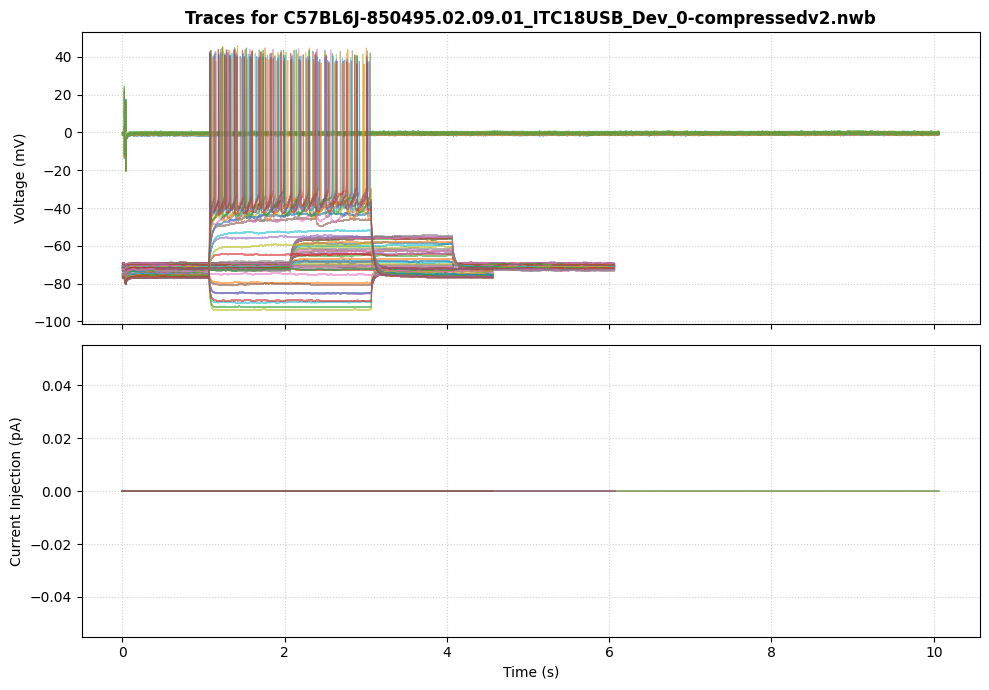

,sweep_num,i_base_pa,i_step_pa,delta_i_pa,v_base_mv,sweep_type
0,0,0.0,0.0,0.0,-0.200000,Baseline / Zero ➖
1,1,0.0,0.0,0.0,-0.000000,Baseline / Zero ➖
2,2,0.0,0.0,0.0,0.300000,Baseline / Zero ➖
3,3,0.0,0.0,0.0,-69.500000,Baseline / Zero ➖
4,4,0.0,0.0,0.0,-69.599998,Baseline / Zero ➖
5,5,0.0,0.0,0.0,-69.400002,Baseline / Zero ➖
6,6,0.0,0.0,0.0,-69.800003,Baseline / Zero ➖
7,7,0.0,0.0,0.0,-70.099998,Baseline / Zero ➖
8,8,0.0,0.0,0.0,-70.699997,Baseline / Zero ➖
9,9,0.0,0.0,0.0,-70.599998,Baseline / Zero ➖



📊 Summary of Current Steps for this NWB File:
  • Hyperpolarizing Sweeps (< -5 pA): 0
  • Depolarizing Sweeps (> +5 pA):   0

💡 Diagnosis: This file contains NO hyperpolarizing sweeps.
  -> Input Resistance (R_in) and Sag Fraction require negative current steps.
  -> That is why r_in_mOhm and sag_fraction are correctly outputting NaN for this file.


In [24]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Select file to troubleshoot (first file or specific path)
sample_file = nwb_files[188]

sweep_summary = []

with h5py.File(sample_file, 'r') as f:
    acq = f['acquisition/timeseries']
    stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else {}
    
    # Sort sweep keys numerically
    sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_") and k.endswith("_AD0")],
                        key=lambda x: int(x.split("_")[1]))
    
    print(f"📁 Inspecting File: {os.path.basename(sample_file)}")
    print(f"Found {len(sweep_keys)} total sweeps.\n")

    fig, (ax_v, ax_i) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for skey in sweep_keys:
        sweep_num = int(skey.split("_")[1])
        v = acq[skey]['data'][:]
        
        # Voltage scaling check (V vs mV)
        if np.max(np.abs(v)) < 0.2:
            v = v * 1000.0
        elif np.max(np.abs(v)) > 200.0:
            v = v / 10.0
            
        # Current scaling check (A vs pA)
        ikey = f"data_{sweep_num}_DA0"
        if ikey in stim:
            i = stim[ikey]['data'][:]
            if np.max(np.abs(i)) < 1e-3:
                i = i * 1e12  # Convert Amperes to pA
        else:
            i = np.zeros_like(v)
            
        # Time vector (seconds)
        if 'timestamps' in acq[skey]:
            t = acq[skey]['timestamps'][:]
            if np.max(t) > 1000:
                t = t / 1000.0
        else:
            t = np.arange(len(v)) / 25000.0
            
        # Baseline current and step current
        base_idx = int(0.1 * 25000) if len(v) > 2500 else 100
        i_base = np.mean(i[:base_idx])
        
        non_zero_i = np.where(np.abs(i - i_base) > 2.0)[0]
        if len(non_zero_i) > 0:
            i_step = np.mean(i[non_zero_i])
        else:
            i_step = i_base
            
        delta_i = i_step - i_base
        
        # Sweep Categorization
        if delta_i < -5.0:
            sweep_type = "Hyperpolarizing 📉"
        elif delta_i > 5.0:
            sweep_type = "Depolarizing 📈"
        else:
            sweep_type = "Baseline / Zero ➖"
            
        sweep_summary.append({
            "sweep_num": sweep_num,
            "i_base_pa": round(i_base, 1),
            "i_step_pa": round(i_step, 1),
            "delta_i_pa": round(delta_i, 1),
            "v_base_mv": round(np.mean(v[:base_idx]), 1),
            "sweep_type": sweep_type
        })
        
        # Plot Traces
        ax_v.plot(t, v, alpha=0.6, lw=0.8)
        ax_i.plot(t, i, alpha=0.6, lw=0.8)

    ax_v.set_ylabel("Voltage (mV)")
    ax_v.set_title(f"Traces for {os.path.basename(sample_file)}", fontweight="bold")
    ax_v.grid(True, linestyle=":", alpha=0.6)
    
    ax_i.set_ylabel("Current Injection (pA)")
    ax_i.set_xlabel("Time (s)")
    ax_i.grid(True, linestyle=":", alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Display Table & Print Counts
df_sweeps = pd.DataFrame(sweep_summary)
display(df_sweeps)

hyper_count = len(df_sweeps[df_sweeps['delta_i_pa'] < -5.0])
depol_count = len(df_sweeps[df_sweeps['delta_i_pa'] > 5.0])

print(f"\n📊 Summary of Current Steps for this NWB File:")
print(f"  • Hyperpolarizing Sweeps (< -5 pA): {hyper_count}")
print(f"  • Depolarizing Sweeps (> +5 pA):   {depol_count}")

if hyper_count == 0:
    print("\n💡 Diagnosis: This file contains NO hyperpolarizing sweeps.")
    print("  -> Input Resistance (R_in) and Sag Fraction require negative current steps.")
    print("  -> That is why r_in_mOhm and sag_fraction are correctly outputting NaN for this file.")

# 1. Environment, paths, metadata download
(Downloads the Google Sheet into a pandas DataFrame and saves a backup with a timestamp)

In [25]:
import os
import glob
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# 1. Path to your network NWB files
DATA_DIR = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types"

# 2. Local directory for saving results
RESULTS_DIR = r"../results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# 3. Google Sheet Metadata Export URL
SHEET_ID = "1CpN3jsWR5c84a57sGSgWtrgvnnLRKjxJgxjQg8Alx1I"
GID = "1820785849"
METADATA_URL = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

# 4. Download Google Sheet and Save Timestamped Backup
try:
    metadata_df = pd.read_csv(METADATA_URL)
    print(f"✅ Successfully loaded Google Sheet metadata ({len(metadata_df)} rows).")
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    meta_filename = f"2025_STR_MSN_analysis_{timestamp}.csv"
    
    os.makedirs("../data/metadata", exist_ok=True)
    meta_save_path = os.path.join("../data/metadata", meta_filename)
    metadata_df.to_csv(meta_save_path, index=False)
    print(f"💾 Saved metadata backup to: {meta_save_path}")
    
except Exception as e:
    print(f"❌ Error downloading Google Sheet: {e}")
    metadata_df = pd.DataFrame()

# 5. Find all NWB files
nwb_files = glob.glob(os.path.join(DATA_DIR, "*.nwb"))
print(f"📁 Found {len(nwb_files)} NWB files in network folder.")

✅ Successfully loaded Google Sheet metadata (198 rows).
💾 Saved metadata backup to: ../data/metadata\2025_STR_MSN_analysis_20260930_145539.csv
📁 Found 219 NWB files in network folder.


# 2. Feature Extractor & Universal NWB Loader
(Includes dynamic current-channel searching to fix NaNs in MIES NWB 1.0 files)

In [ ]:
#v7 USE THIS ONE
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents, access_res_list = [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            stim_comment = ""
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    stim_comment = str(cand_obj.attrs.get('comments', '')) + " " + str(cand_obj.attrs.get('description', ''))
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # --- Holding Current Extraction ---
            i_hold_val = i_base
            if abs(i_hold_val) < 0.1 and stim_comment:
                i_hold_match = re.search(r"(?:I-Clamp Holding Level|Autobias Ibias):\s*([-\d\.]+)\s*pA", stim_comment)
                if i_hold_match: i_hold_val = float(i_hold_match.group(1))
            holding_currents.append(i_hold_val)

            # --- Ground-Truth Access Resistance (Header Bridge Bal / VC Test Pulses Only) ---
            if stim_comment:
                ra_match = re.search(r"(?:Bridge Bal Value|Series Resistance):\s*([-\d\.]+)\s*M", stim_comment)
                if ra_match:
                    ra_val = float(ra_match.group(1))
                    if 5.0 <= ra_val <= 80.0: access_res_list.append(ra_val)

            # Voltage Clamp Test Pulse Calculation
            if np.max(np.abs(v)) > 2.0 and np.max(np.abs(v)) < 15.0 and np.max(np.abs(i)) > 50.0:
                v_step_mv = np.max(np.abs(v - np.mean(v[:500])))
                i_peak_pa = np.max(np.abs(i - i_base))
                if i_peak_pa > 0:
                    ra_vc = (v_step_mv / i_peak_pa) * 1000.0
                    if 5.0 <= ra_vc <= 80.0: access_res_list.append(ra_vc)

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Subthreshold Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            "cell_access(mOhms)": np.median(access_res_list) if access_res_list else np.nan,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    return feats

In [65]:
#v6
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents, access_res_list = [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        supra_cv_isi_calc = np.nan
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            stim_comment = ""
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    stim_comment = str(cand_obj.attrs.get('comments', '')) + " " + str(cand_obj.attrs.get('description', ''))
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # --- Extract Holding Current ---
            i_hold_val = i_base
            if abs(i_hold_val) < 0.1 and stim_comment:
                i_hold_match = re.search(r"I-Clamp Holding Level:\s*([-\d\.]+)\s*pA", stim_comment)
                if i_hold_match: i_hold_val = float(i_hold_match.group(1))
            holding_currents.append(i_hold_val)

            # --- Extract Access Resistance (Relaxed Filters to Accept Values < 5.0) ---
            if stim_comment:
                ra_match = re.search(r"(?:Series Resistance|Bridge Bal Value):\s*([-\d\.]+)\s*M", stim_comment)
                if ra_match:
                    ra_val = float(ra_match.group(1))
                    if 0.1 <= ra_val <= 150.0: access_res_list.append(ra_val)

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- SUBTHRESHOLD FEATURES (Hyperpolarizing) ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)
                        
                    # Uncompensated Trace Access Resistance
                    v_inst = np.mean(v[p_start + 2 : p_start + 5])
                    delta_v_inst = v_inst - v_base
                    ra_est = (delta_v_inst / delta_i) * 1000.0
                    if 0.1 <= ra_est <= 120.0: access_res_list.append(ra_est)

                # --- ACTIVE SPIKING FEATURES (Depolarizing) ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                            
                            # Manual CV_ISI calculation if >= 3 spikes exist
                            if num_spikes >= 3 and 'threshold_t' in spikes.columns:
                                isis = np.diff(spikes['threshold_t'].values)
                                supra_cv_isi_calc = np.std(isis) / np.mean(isis) if np.mean(isis) > 0 else np.nan
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        # Use explicit calculated CV_ISI if IPFX returned NaN
        final_cv_isi = supra_train_features.get('cv_isi', np.nan)
        if pd.isna(final_cv_isi):
            final_cv_isi = supra_cv_isi_calc

        return {
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            "cell_access(mOhms)": np.median(access_res_list) if access_res_list else np.nan,
            
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": final_cv_isi,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    return feats

In [59]:
#v5
import os
import re
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """Calculates AP half-width via exact linear interpolation at V_half."""
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    # 1. Rising Phase
    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0: return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    # 2. Falling Phase
    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0: return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak): return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))  # 2 ms post-peak
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))    # 25 ms post-peak
    
    if idx_end <= idx_start: return np.nan
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents, access_res_list = [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            stim_comment = ""
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if isinstance(cand_obj, h5py.Group):
                    stim_comment = str(cand_obj.attrs.get('comments', '')) + " " + str(cand_obj.attrs.get('description', ''))
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            # Time vector
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            # --- Holding Current ---
            i_hold_val = i_base
            if abs(i_hold_val) < 0.1 and stim_comment:
                i_hold_match = re.search(r"I-Clamp Holding Level:\s*([-\d\.]+)\s*pA", stim_comment)
                if i_hold_match: i_hold_val = float(i_hold_match.group(1))
            holding_currents.append(i_hold_val)

            # --- Accurate Access Resistance (VC Test Pulses or Amplifier Bridge Balance) ---
            if stim_comment:
                ra_match = re.search(r"(?:Series Resistance|Bridge Bal Value):\s*([-\d\.]+)\s*M", stim_comment)
                if ra_match:
                    ra_val = float(ra_match.group(1))
                    if 5.0 <= ra_val <= 60.0: access_res_list.append(ra_val)

            # Check if sweep is Voltage Clamp Test Pulse (for direct Ra calculation)
            if np.max(np.abs(v)) > 2.0 and np.max(np.abs(v)) < 15.0 and np.max(np.abs(i)) > 50.0:
                v_step_mv = np.max(np.abs(v - np.mean(v[:500])))
                i_peak_pa = np.max(np.abs(i - i_base))
                if i_peak_pa > 0:
                    ra_vc = (v_step_mv / i_peak_pa) * 1000.0  # MOhms
                    if 5.0 <= ra_vc <= 60.0: access_res_list.append(ra_vc)

            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- SUBTHRESHOLD FEATURES (Hyperpolarizing steps: ΔI < 0) ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)

                # --- ACTIVE SPIKING FEATURES (Depolarizing steps: ΔI > 0) ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        # Identify Rheobase Sweep (minimal current for ≥1 AP)
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        # Identify Suprathreshold Sweep (max firing step)
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        # Rheobase Calculations
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        # Suprathreshold Calculations
        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        return {
            # --- Calculated NWB Metrics ---
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            "cell_access(mOhms)": np.median(access_res_list) if access_res_list else np.nan,
            
            # --- Passive Subthreshold Properties ---
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            # --- Rheobase Sweep Metrics ---
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            # --- AP Accommodation Ratios ---
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            # --- Suprathreshold Sweep Metrics ---
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,
            "suprathreshold_sweep_cv_isi": supra_train_features.get('cv_isi', np.nan),
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_path"] = file_path
    return feats

In [55]:
#v4 38 features complete

import os
import h5py
import pandas as pd
import numpy as np
from datetime import datetime
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    """Detects NWB major version using PyNWB as ground truth."""
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"): return "2.0"
        except Exception:
            pass
        return "1.0"


def calc_ap_half_width(t, v, t_thresh, t_peak, v_thresh, v_peak):
    """
    Calculates AP half-width via exact linear interpolation at V_half.
    Replaces IPFX auto-defaults (e.g. 1.0 ms).
    """
    if np.isnan(v_thresh) or np.isnan(v_peak) or v_peak <= v_thresh or np.isnan(t_thresh) or np.isnan(t_peak):
        return np.nan
    
    v_half = v_thresh + 0.5 * (v_peak - v_thresh)
    
    idx_thresh = np.argmin(np.abs(t - t_thresh))
    idx_peak = np.argmin(np.abs(t - t_peak))
    
    if idx_peak <= idx_thresh:
        return np.nan

    # 1. Interpolate Rising Phase
    v_rise = v[idx_thresh : idx_peak + 1]
    t_rise = t[idx_thresh : idx_peak + 1]
    
    above_half_rise = np.where(v_rise >= v_half)[0]
    if len(above_half_rise) == 0:
        return np.nan
    i_rise = above_half_rise[0]
    if i_rise == 0:
        t_half_rise = t_rise[0]
    else:
        v0, v1 = v_rise[i_rise - 1], v_rise[i_rise]
        t0, t1 = t_rise[i_rise - 1], t_rise[i_rise]
        t_half_rise = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    # 2. Interpolate Falling Phase (up to 10 ms post-peak)
    idx_end = min(len(v) - 1, idx_peak + int(0.010 * 25000))
    v_fall = v[idx_peak : idx_end]
    t_fall = t[idx_peak : idx_end]
    
    below_half_fall = np.where(v_fall <= v_half)[0]
    if len(below_half_fall) == 0:
        return np.nan
    i_fall = below_half_fall[0]
    if i_fall == 0:
        t_half_fall = t_fall[0]
    else:
        v0, v1 = v_fall[i_fall - 1], v_fall[i_fall]
        t0, t1 = t_fall[i_fall - 1], t_fall[i_fall]
        t_half_fall = t0 + (v_half - v0) * (t1 - t0) / (v1 - v0) if v1 != v0 else t0

    width_ms = (t_half_fall - t_half_rise) * 1000.0
    return width_ms if 0.05 <= width_ms <= 15.0 else np.nan


def calc_adp_v(t, v, t_peak):
    """Calculates After-Depolarization (ADP) voltage rebound post-spike."""
    if np.isnan(t_peak):
        return np.nan
    idx_peak = np.argmin(np.abs(t - t_peak))
    idx_start = min(len(v) - 1, idx_peak + int(0.002 * 25000))  # 2 ms post-peak
    idx_end = min(len(v) - 1, idx_peak + int(0.025 * 25000))    # 25 ms post-peak
    
    if idx_end <= idx_start:
        return np.nan
    
    window_v = v[idx_start:idx_end]
    return float(np.max(window_v)) if len(window_v) > 0 else np.nan


def extract_all_features_universal(file_path):
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries'] if 'acquisition/timeseries' in f else f['acquisition']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else f.get('stimulus', {})
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        holding_currents, access_res_list = [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        rheo_t, rheo_v = None, None
        
        # Tracking lowest sweep with >=3 spikes for CV ISI fallback
        cv_isi_fallback = np.nan
        min_spikes_for_cv = np.inf
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        supra_t, supra_v = None, None
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)): continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2: v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0: i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                holding_currents.append(i_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # --- Passive Features ---
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)
                        
                    # Cell Access Resistance (Ra) from immediate uncharged Vm drop
                    v_inst = np.mean(v[p_start + 2 : p_start + 5])
                    delta_v_inst = v_inst - v_base
                    ra_est = (delta_v_inst / delta_i) * 1000.0
                    if 0 < ra_est < 120: access_res_list.append(ra_est)

                # --- Active Spiking Features ---
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        # Populate CV_ISI from lowest sweep with >= 3 spikes
                        if num_spikes >= 3 and delta_i < min_spikes_for_cv:
                            min_spikes_for_cv = delta_i
                            cv_isi_fallback = train_feats.get('cv_isi', np.nan)

                        # Rheobase Sweep Identification
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            rheo_t, rheo_v = t, v
                            
                        # Suprathreshold Sweep Identification
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                            supra_t, supra_v = t, v
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # --- Aggregations & Manual Metric Calculations ---
        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0] if len(fi_stims) > 1 else np.nan
        
        # Rheobase Spikes & Custom Calculations
        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk
        
        # 1. Calculated Rheobase AP Half-Width (Replacing Auto Default)
        rheo_ap_width = calc_ap_half_width(
            rheo_t, rheo_v,
            first_spk.get('threshold_t', np.nan), first_spk.get('peak_t', np.nan),
            first_spk.get('threshold_v', np.nan), first_spk.get('peak_v', np.nan)
        ) if rheo_t is not None else np.nan

        # 2. Calculated ADP Voltage
        rheo_adp_v = first_spk.get('adp_v', np.nan)
        if pd.isna(rheo_adp_v) and rheo_t is not None:
            rheo_adp_v = calc_adp_v(rheo_t, rheo_v, first_spk.get('peak_t', np.nan))

        # 3. CV ISI Population (Rheobase if >=3 spikes, else lowest sweep with >=3 spikes)
        rheo_cv_isi = rheo_train_features.get('cv_isi', np.nan)
        if pd.isna(rheo_cv_isi):
            rheo_cv_isi = cv_isi_fallback

        # Suprathreshold Spikes & Custom Calculations
        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}
        
        supra_ap_width = calc_ap_half_width(
            supra_t, supra_v,
            supra_first_spk.get('threshold_t', np.nan), supra_first_spk.get('peak_t', np.nan),
            supra_first_spk.get('threshold_v', np.nan), supra_first_spk.get('peak_v', np.nan)
        ) if supra_t is not None else np.nan

        return {
            # --- Requested Calculated Columns ---
            "v_rest(mV)": v_baseline_final,
            "holding_current(pA)": np.median(holding_currents) if holding_currents else np.nan,
            "cell_access(mOhms)": np.median(access_res_list) if access_res_list else np.nan,
            
            # --- Passive & FI Properties ---
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            
            # --- Rheobase Sweep Features ---
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": rheo_ap_width,  # Calculated width
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": rheo_adp_v,      # Populated ADP V
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_cv_isi": rheo_cv_isi,    # Populated CV ISI
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            
            # --- AP Accommodation Ratios ---
            "ap_width_ratio": (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan,
            "ap_height_ratio": ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "ap_upstroke_ratio": (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan,
            
            # --- Suprathreshold Sweep Features ---
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_ap_width,  # Calculated width
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_basename = os.path.basename(file_path).lower()
    cell_name = cell_basename
    
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']) and os.path.basename(str(row['file_path'])).lower() == cell_basename:
                cell_name = str(row['cell_name']).strip()
                break
                
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = inspect_nwb_version(file_path)
    feats["cell_name"] = cell_name
    feats["file_name"] = os.path.basename(file_path)
    return feats

In [49]:
#v3 38 features
import os
import h5py
import pandas as pd
import numpy as np
from pynwb import NWBHDF5IO

from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    """Detects major NWB version using PyNWB as ground truth."""
    try:
        with NWBHDF5IO(file_path, 'r', load_namespaces=True) as io:
            _ = io.read()
            return "2.0"
    except TypeError:
        return "1.0"
    except Exception:
        try:
            with h5py.File(file_path, 'r') as f:
                ver = f.attrs.get("nwb_version", "")
                if hasattr(ver, 'decode'): ver = ver.decode('utf-8')
                if "2." in str(ver) or str(ver).startswith("2"):
                    return "2.0"
        except Exception:
            pass
        return "1.0"


def get_cell_name_from_metadata(file_path, meta_df):
    """Matches NWB file path/name with official cell_name in Google Sheet metadata."""
    file_basename = os.path.basename(file_path).lower()
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']):
                meta_basename = os.path.basename(str(row['file_path'])).lower()
                if file_basename == meta_basename:
                    return str(row['cell_name']).strip()
    return os.path.splitext(file_basename)[0]


def extract_all_features_universal(file_path):
    """Extracts 38 intrinsic electrophysiology metrics across subthreshold & suprathreshold sweeps."""
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        if 'acquisition/timeseries' in f:
            acq = f['acquisition/timeseries']
        elif 'acquisition' in f:
            acq = f['acquisition']
        else:
            raise KeyError("Could not find acquisition group in NWB file.")
            
        if 'stimulus/presentation' in f:
            stim = f['stimulus/presentation']
        elif 'stimulus' in f:
            stim = f['stimulus']
        else:
            stim = {}
            
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_")],
                            key=lambda x: int(x.split("_")[1]) if len(x.split("_")) > 1 and x.split("_")[1].isdigit() else 0)
        
        baselines, r_in_list, sag_list, tau_list = [], [], [], []
        
        lowest_rheo_i = np.inf
        rheo_spikes_df = None
        rheo_train_features = {}
        rheo_stim_amp = np.nan
        
        max_spikes_count = 0
        max_firing_rate = 0.0
        supra_stim_amp = np.nan
        supra_spikes_df = None
        supra_train_features = {}
        
        fi_stims, fi_rates = [], []
        
        for skey in sweep_keys:
            if not isinstance(acq[skey], (h5py.Dataset, h5py.Group)):
                continue
                
            sweep_num = skey.split("_")[1] if len(skey.split("_")) > 1 else "0"
            
            v_obj = acq[skey]
            v = v_obj['data'][:] if isinstance(v_obj, h5py.Group) and 'data' in v_obj else v_obj[:]
            if np.max(np.abs(v)) < 0.2:
                v = v * 1000.0  # V -> mV
                
            i = np.zeros_like(v)
            possible_i_keys = [k for k in stim.keys() if f"_{sweep_num}_" in k or k.endswith(f"_{sweep_num}")]
            for k in possible_i_keys:
                cand_obj = stim[k]
                candidate_i = cand_obj['data'][:] if isinstance(cand_obj, h5py.Group) and 'data' in cand_obj else cand_obj[:]
                if np.max(np.abs(candidate_i)) > 0:
                    i = candidate_i
                    break
                    
            if np.max(np.abs(i)) < 1e-3 and np.max(np.abs(i)) > 0:
                i = i * 1e12  # A -> pA
                
            if isinstance(v_obj, h5py.Group) and 'timestamps' in v_obj:
                t = v_obj['timestamps'][:]
                if np.max(t) > 1000: t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                sweep_duration_sec = t[p_end] - t[p_start]
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # Hyperpolarizing Sweeps
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0
                    if 10 < r_in < 1500: r_in_list.append(r_in)
                    
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0: sag_list.append(sag)
                        
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0: tau_list.append(tau_ms)
                        
                # Depolarizing Sweeps
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        firing_rate = num_spikes / sweep_duration_sec
                        
                        fi_stims.append(delta_i)
                        fi_rates.append(firing_rate)
                        
                        train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                        train_feats = train_extractor.process(t, v, i, spikes) if num_spikes > 0 else {}
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            rheo_stim_amp = delta_i
                            rheo_spikes_df = spikes
                            rheo_train_features = train_feats
                            
                        if num_spikes > max_spikes_count:
                            max_spikes_count = num_spikes
                            max_firing_rate = firing_rate
                            supra_stim_amp = delta_i
                            supra_spikes_df = spikes
                            supra_train_features = train_feats
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        v_baseline_final = np.mean(baselines) if baselines else np.nan
        r_in_final = np.median(r_in_list) if r_in_list else np.nan
        tau_final = np.median(tau_list) if tau_list else np.nan
        capacitance_final = (tau_final * 1000.0 / r_in_final) if pd.notna(tau_final) and pd.notna(r_in_final) and r_in_final > 0 else np.nan

        fi_slope = np.nan
        if len(fi_stims) > 1:
            try: fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0]
            except Exception: pass

        first_spk = rheo_spikes_df.iloc[0] if rheo_spikes_df is not None and not rheo_spikes_df.empty else {}
        last_spk = rheo_spikes_df.iloc[-1] if rheo_spikes_df is not None and len(rheo_spikes_df) > 1 else first_spk

        ap_width_ratio = (last_spk.get('width', np.nan) / first_spk.get('width', np.nan)) if pd.notna(first_spk.get('width')) and first_spk.get('width') > 0 else np.nan
        ap_height_ratio = ((last_spk.get('peak_v', np.nan) - last_spk.get('threshold_v', np.nan)) / 
                           (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan))) if pd.notna(first_spk.get('peak_v')) else np.nan
        ap_upstroke_ratio = (last_spk.get('upstroke', np.nan) / first_spk.get('upstroke', np.nan)) if pd.notna(first_spk.get('upstroke')) and first_spk.get('upstroke') > 0 else np.nan

        supra_first_spk = supra_spikes_df.iloc[0] if supra_spikes_df is not None and not supra_spikes_df.empty else {}

        return {
            "v_baseline": v_baseline_final,
            "input_resistance": r_in_final,
            "tau": tau_final,
            "capacitance": capacitance_final,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            "max_firing_rate": max_firing_rate,
            "rheobase_sweep_stim_amp": rheo_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "rheobase_sweep_spike_count": len(rheo_spikes_df) if rheo_spikes_df is not None else 0,
            "rheobase_sweep_threshold_t": first_spk.get('threshold_t', np.nan),
            "rheobase_sweep_peak_t": first_spk.get('peak_t', np.nan),
            "rheobase_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "rheobase_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "rheobase_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "rheobase_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "rheobase_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "rheobase_sweep_width": first_spk.get('width', np.nan) * 1000.0 if pd.notna(first_spk.get('width')) else np.nan,
            "rheobase_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "rheobase_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "rheobase_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "rheobase_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "rheobase_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            "rheobase_sweep_adp_v": first_spk.get('adp_v', np.nan),
            "rheobase_sweep_latency": rheo_train_features.get('latency', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('latency')) else np.nan,
            "rheobase_sweep_adaptation_index": rheo_train_features.get('adapt', np.nan),
            "rheobase_sweep_mean_isi": rheo_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('mean_isi')) else np.nan,
            "rheobase_sweep_first_isi": rheo_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(rheo_train_features.get('first_isi')) else np.nan,
            "rheobase_sweep_cv_isi": rheo_train_features.get('cv_isi', np.nan),
            "rheobase_sweep_avg_rate": rheo_train_features.get('avg_rate', np.nan),
            "ap_width_ratio": ap_width_ratio,
            "ap_height_ratio": ap_height_ratio,
            "ap_upstroke_ratio": ap_upstroke_ratio,
            "suprathreshold_sweep_stim_amp": supra_stim_amp,
            "suprathreshold_sweep_spike_count": max_spikes_count,
            "suprathreshold_sweep_threshold_v": supra_first_spk.get('threshold_v', np.nan),
            "suprathreshold_sweep_peak_v": supra_first_spk.get('peak_v', np.nan),
            "suprathreshold_sweep_width": supra_first_spk.get('width', np.nan) * 1000.0 if pd.notna(supra_first_spk.get('width')) else np.nan,
            "suprathreshold_sweep_adaptation_index": supra_train_features.get('adapt', np.nan)
        }


def process_file_universal(file_path, meta_df):
    cell_name = get_cell_name_from_metadata(file_path, meta_df)
    file_name = os.path.basename(file_path)
    version = inspect_nwb_version(file_path)
    
    feats = extract_all_features_universal(file_path)
    feats["nwb_version"] = version
    feats["cell_name"] = cell_name
    feats["file_name"] = file_name
    
    return feats

In [38]:
import os
import h5py
import pandas as pd
import numpy as np

from ipfx.dataset.create import create_ephys_data_set
from ipfx.data_set_features import extract_data_set_features
from ipfx.feature_extractor import SpikeFeatureExtractor, SpikeTrainFeatureExtractor


def inspect_nwb_version(file_path):
    """Detects whether an NWB file is version 1.0 or 2.0."""
    try:
        with h5py.File(file_path, 'r') as f:
            if "nwb_version" in f.attrs:
                ver = f.attrs["nwb_version"]
                return str(ver.decode('utf-8') if isinstance(ver, bytes) else ver)
            elif "nwb_version" in f:
                ver = f["nwb_version"][()]
                return str(ver.decode('utf-8') if isinstance(ver, bytes) else ver)
    except Exception:
        pass
    return "1.0"


def get_cell_name_from_metadata(file_path, meta_df):
    """Matches NWB file path/name with official cell_name in Google Sheet metadata."""
    file_basename = os.path.basename(file_path).lower()
    if 'file_path' in meta_df.columns and 'cell_name' in meta_df.columns:
        for _, row in meta_df.iterrows():
            if pd.notna(row['file_path']):
                meta_basename = os.path.basename(str(row['file_path'])).lower()
                if file_basename == meta_basename:
                    return str(row['cell_name']).strip()
    return os.path.splitext(file_basename)[0]


def extract_features_nwb2(file_path):
    """Extracts all 30+ IPFX features from NWB 2.0 datasets and flattens nested dictionaries."""
    data_set = create_ephys_data_set(nwb_file=file_path)
    cell_features, _ = extract_data_set_features(data_set)
    
    flat_features = {}
    
    # Extract top-level cell features
    for k, v in cell_features.items():
        if isinstance(v, dict):
            # Flatten sub-dictionaries (hero_sweep, rheobase_sweep, etc.)
            for sub_k, sub_v in v.items():
                if not isinstance(sub_v, (dict, list)):
                    flat_features[f"{k}_{sub_k}"] = sub_v
        elif not isinstance(v, (dict, list)):
            flat_features[k] = v
            
    return flat_features


def extract_features_nwb1_h5py(file_path):
    """Extracts 30+ intrinsic ephys features from NWB 1.0 files via h5py and IPFX feature extractors."""
    spike_extractor = SpikeFeatureExtractor()
    
    with h5py.File(file_path, 'r') as f:
        acq = f['acquisition/timeseries']
        stim = f['stimulus/presentation'] if 'stimulus/presentation' in f else {}
        
        sweep_keys = sorted([k for k in acq.keys() if k.startswith("data_") and k.endswith("_AD0")],
                            key=lambda x: int(x.split("_")[1]))
        
        baselines = []
        r_in_list = []
        sag_list = []
        tau_list = []
        
        lowest_rheo_i = np.inf
        hero_spikes_df = None
        hero_train_features = {}
        hero_stim_amp = np.nan
        
        # Fi curve tracking
        fi_stims = []
        fi_rates = []
        
        for skey in sweep_keys:
            sweep_num = skey.split("_")[1]
            v = acq[skey]['data'][:]
            
            ikey = f"data_{sweep_num}_DA0"
            i = stim[ikey]['data'][:] if ikey in stim else np.zeros_like(v)
            
            # Time vector in seconds
            if 'timestamps' in acq[skey]:
                t = acq[skey]['timestamps'][:]
                if np.max(t) > 1000:
                    t = t / 1000.0
            else:
                t = np.arange(len(v)) / 25000.0
                
            base_len = min(1000, len(i) // 10)
            i_base = np.mean(i[:base_len])
            pulse_idx = np.where(np.abs(i - i_base) > 2.0)[0]
            
            if len(pulse_idx) > 100:
                p_start = pulse_idx[0]
                p_end = pulse_idx[-1]
                p_len = p_end - p_start
                
                i_step = np.mean(i[p_start + int(p_len * 0.1) : p_end - int(p_len * 0.1)])
                delta_i = i_step - i_base
                
                v_base = np.mean(v[max(0, p_start - 1000) : max(1, p_start - 50)])
                baselines.append(v_base)
                
                v_steady = np.mean(v[max(p_start, p_end - int(p_len * 0.2)) : p_end])
                v_trough = np.min(v[p_start : p_end])
                delta_v = v_steady - v_base
                
                # Hyperpolarizing sweeps (R_in, Sag, Tau)
                if delta_i < -5.0:
                    r_in = (delta_v / delta_i) * 1000.0  # MOhms
                    if 10 < r_in < 1500:
                        r_in_list.append(r_in)
                        
                    if abs(v_trough - v_base) > 1.0:
                        sag = (v_trough - v_steady) / (v_trough - v_base)
                        if 0 <= sag <= 1.0:
                            sag_list.append(sag)
                            
                    # Membrane time constant (Tau estimate: 63.2% of steady state)
                    v_target = v_base + 0.632 * delta_v
                    tau_idx = np.where(v[p_start:p_end] <= v_target)[0] if delta_v < 0 else np.where(v[p_start:p_end] >= v_target)[0]
                    if len(tau_idx) > 0:
                        tau_ms = (t[p_start + tau_idx[0]] - t[p_start]) * 1000.0
                        if 0.5 < tau_ms < 200.0:
                            tau_list.append(tau_ms)
                            
                # Depolarizing spiking sweeps
                if np.max(v) > -10.0 and delta_i > 5.0:
                    try:
                        spikes = spike_extractor.process(t, v, i)
                        num_spikes = len(spikes)
                        
                        fi_stims.append(delta_i)
                        fi_rates.append(num_spikes / ((t[p_end] - t[p_start])))
                        
                        if num_spikes > 0 and delta_i < lowest_rheo_i:
                            lowest_rheo_i = delta_i
                            hero_stim_amp = delta_i
                            hero_spikes_df = spikes
                            
                            train_extractor = SpikeTrainFeatureExtractor(start=t[p_start], end=t[p_end])
                            hero_train_features = train_extractor.process(t, v, i, spikes)
                    except Exception:
                        pass
            else:
                baselines.append(np.mean(v[:base_len]))

        # Calculate f-I curve slope
        fi_slope = np.nan
        if len(fi_stims) > 1:
            try:
                fi_slope = np.polyfit(fi_stims, fi_rates, 1)[0]
            except Exception:
                pass

        # Extract first action potential metrics from hero sweep
        first_spk = hero_spikes_df.iloc[0] if hero_spikes_df is not None and not hero_spikes_df.empty else {}

        return {
            # Passive Membrane Properties
            "v_baseline": np.mean(baselines) if baselines else np.nan,
            "input_resistance": np.median(r_in_list) if r_in_list else np.nan,
            "tau": np.median(tau_list) if tau_list else np.nan,
            "sag": np.median(sag_list) if sag_list else np.nan,
            "f_i_curve_slope": fi_slope,
            
            # Hero Sweep Spiking & Waveform Features
            "hero_sweep_stim_amp": hero_stim_amp if lowest_rheo_i != np.inf else np.nan,
            "hero_sweep_threshold_v": first_spk.get('threshold_v', np.nan),
            "hero_sweep_threshold_i": first_spk.get('threshold_i', np.nan),
            "hero_sweep_peak_v": first_spk.get('peak_v', np.nan),
            "hero_sweep_peak_i": first_spk.get('peak_i', np.nan),
            "hero_sweep_ap_amplitude": (first_spk.get('peak_v', np.nan) - first_spk.get('threshold_v', np.nan)) if pd.notna(first_spk.get('peak_v')) else np.nan,
            "hero_sweep_width": first_spk.get('width', np.nan) * 1000.0,  # ms
            "hero_sweep_upstroke": first_spk.get('upstroke', np.nan),
            "hero_sweep_downstroke": first_spk.get('downstroke', np.nan),
            "hero_sweep_upstroke_downstroke_ratio": first_spk.get('upstroke_downstroke_ratio', np.nan),
            "hero_sweep_trough_v": first_spk.get('trough_v', np.nan),
            "hero_sweep_fast_trough_v": first_spk.get('fast_trough_v', np.nan),
            
            # Train Dynamics Metrics
            "hero_sweep_adaptation_index": hero_train_features.get('adapt', np.nan),
            "hero_sweep_latency": hero_train_features.get('latency', np.nan) * 1000.0 if pd.notna(hero_train_features.get('latency')) else np.nan,
            "hero_sweep_mean_isi": hero_train_features.get('mean_isi', np.nan) * 1000.0 if pd.notna(hero_train_features.get('mean_isi')) else np.nan,
            "hero_sweep_first_isi": hero_train_features.get('first_isi', np.nan) * 1000.0 if pd.notna(hero_train_features.get('first_isi')) else np.nan,
            "hero_sweep_avg_rate": hero_train_features.get('avg_rate', np.nan),
        }

In [54]:
t adds v_rest(mV), holding_current(pA), and an instantaneous cell_access(mOhms) calculation (derived from the immediate voltage drop before the membrane charges).

It drops your specified Google Sheet columns.

It sorts the final dataset chronologically by date.

SyntaxError: invalid syntax (82299714.py, line 1)

# 3. Single Cell Feature Test

In [68]:
import pandas as pd

# Test mix including a known spiking step file
test_files = [f for f in nwb_files if "850495" in f or "880646" in f][:3]
if not test_files:
    test_files = nwb_files[:3]

test_rows = []
for fpath in test_files:
    feats = process_file_universal(fpath, metadata_df)
    test_rows.append(feats)

df_test_check = pd.DataFrame(test_rows)

print("📊 PRE-BATCH VERIFICATION SUMMARY:")
display(df_test_check[[
    "cell_name", "v_rest(mV)", "holding_current(pA)", 
    "cell_access(mOhms)", "suprathreshold_sweep_cv_isi", 
    "rheobase_sweep_width", "rheobase_sweep_adp_v"
]])

📊 PRE-BATCH VERIFICATION SUMMARY:


,cell_name,v_rest(mV),holding_current(pA),cell_access(mOhms),suprathreshold_sweep_cv_isi,rheobase_sweep_width,rheobase_sweep_adp_v
0,Ai14-Het-880646.01.09.02,-57.162716,0.0,NaN,NaN,2.830110,-5.50000
1,Ai14-Het-880646.01.09.04,-70.009834,0.0,NaN,0.093509,2.002064,-4.03125
2,Ai14-Het-880646.01.09.05,-68.388672,0.0,NaN,0.369207,3.909111,-3.46875


In [69]:
import pandas as pd
import numpy as np

# 1. Select 5 sample files (mix of subthreshold and spiking files if available)
sample_files = nwb_files[:5]

test_rows = []
print(f"🔬 Running pre-batch verification on {len(sample_files)} sample files...\n")

for fpath in sample_files:
    fname = os.path.basename(fpath)
    try:
        feats = process_file_universal(fpath, metadata_df)
        test_rows.append(feats)
        print(f"  • Extracted: {feats['cell_name']}")
    except Exception as e:
        print(f"  ❌ Error on {fname}: {e}")

df_ephys_test = pd.DataFrame(test_rows)

# 2. Clean Metadata Pre-Merge (Drops overlapping columns from Google Sheet)
meta_cols_to_drop_pre_merge = ['v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)', 'file_name', 'file_path']
if not metadata_df.empty:
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name']).copy()
    meta_clean.drop(columns=[c for c in meta_cols_to_drop_pre_merge if c in meta_clean.columns], inplace=True)
    df_merged_test = pd.merge(df_ephys_test, meta_clean, on='cell_name', how='left')
else:
    df_merged_test = df_ephys_test

# 3. Clean Date Conversion (Strict YYMMDD)
if 'date' in df_merged_test.columns:
    date_str = df_merged_test['date'].astype(str).str.split('.').str[0].str.zfill(6)
    parsed_dates = pd.to_datetime(date_str, format='%y%m%d', errors='coerce')
    mask_na = parsed_dates.isna()
    if mask_na.any():
        parsed_dates[mask_na] = pd.to_datetime(df_merged_test.loc[mask_na, 'date'], errors='coerce')
    df_merged_test['date'] = parsed_dates.dt.strftime('%y%m%d')

# -------------------------------------------------------------------------
# VERIFICATION CHECKS
# -------------------------------------------------------------------------
print("\n" + "=" * 70)
print("📊 PRE-BATCH SANITY CHECK RESULTS")
print("=" * 70)

# Check 1: Ensure NO '_x' or '_y' suffixes exist in columns
xy_cols = [c for c in df_merged_test.columns if c.endswith('_x') or c.endswith('_y')]
if len(xy_cols) == 0:
    print("✅ CHECK 1 PASSED: Zero '_x' or '_y' duplicate columns detected!")
else:
    print(f"⚠️ CHECK 1 FAILED: Found duplicate columns: {xy_cols}")

# Check 2: Verify calculated target metrics
target_cols = [
    'date', 'cell_name', 'v_rest(mV)', 'holding_current(pA)', 
    'cell_access(mOhms)', 'suprathreshold_sweep_cv_isi', 
    'rheobase_sweep_width', 'rheobase_sweep_adp_v'
]

display_cols = [c for c in target_cols if c in df_merged_test.columns]

print(f"\n✅ Preview of Target Calculated Columns across sample:")
display(df_merged_test[display_cols])

🔬 Running pre-batch verification on 5 sample files...

  • Extracted: C57BL6J-803061.01.01
  • Extracted: C57BL6J-803061.01.02
  • Extracted: C57BL6J-795017.01.01
  • Extracted: C57BL6J-795017.01.02
  • Extracted: C57BL6J-795017.01.03

📊 PRE-BATCH SANITY CHECK RESULTS
✅ CHECK 1 PASSED: Zero '_x' or '_y' duplicate columns detected!

✅ Preview of Target Calculated Columns across sample:


,date,cell_name,v_rest(mV),holding_current(pA),cell_access(mOhms),suprathreshold_sweep_cv_isi,rheobase_sweep_width,rheobase_sweep_adp_v
0,250527,C57BL6J-803061.01.01,-38.062729,4.17,NaN,0.168576,1.341489,-22.84375
1,250527,C57BL6J-803061.01.02,24.160673,-20.85,NaN,0.139260,1.630098,-26.78125
2,250603,C57BL6J-795017.01.01,-41.391449,-20.85,NaN,0.191851,1.773690,-25.50000
3,250603,C57BL6J-795017.01.02,-58.962170,-20.85,NaN,0.150700,2.390850,-12.68750
4,250603,C57BL6J-795017.01.03,-99.490135,-20.85,NaN,0.229519,1.678196,-20.93750


Run this test cell in your notebook to sample 10 cells (including random samples and specific test cells) and verify feature extraction across your dataset:

In [70]:
import random
import pandas as pd

# 1. Select a sample batch (10 files)
sample_size = 10

# Take a random sample from nwb_files
sample_files = random.sample(nwb_files, min(sample_size, len(nwb_files)))

# Always include specific test cells if present in your dataset
target_filenames = ["Ai14-Het-880646.03.03.01.nwb", "C57BL6J-850495.02.09.01_ITC18USB_Dev_0-compressedv2.nwb"]
for t_fn in target_filenames:
    matched = [f for f in nwb_files if t_fn.lower() in os.path.basename(f).lower()]
    if matched and matched[0] not in sample_files:
        sample_files[0] = matched[0]

multi_test_results = []

print(f"🔬 Testing multi-cell feature extraction on {len(sample_files)} sample NWB files...\n")

# 2. Process sample loop
for idx, fpath in enumerate(sample_files, start=1):
    try:
        feats = process_file_universal(fpath, metadata_df)
        multi_test_results.append(feats)
        print(f"[{idx:02d}/{len(sample_files):02d}] ✅ Processed: {feats['cell_name']:30s} | NWB {feats['nwb_version']:3s} | Keys: {len(feats)}")
    except Exception as e:
        print(f"[{idx:02d}/{len(sample_files):02d}] ❌ Error on {os.path.basename(fpath)}: {e}")

# 3. Convert to DataFrame
df_multi_test = pd.DataFrame(multi_test_results)

# 4. Print Summary Verification
print("\n" + "=" * 70)
print("📊 MULTI-CELL EXTRACTION VERIFICATION SUMMARY")
print("=" * 70)
print(f"• Total Cells Processed       : {len(df_multi_test)}")
print(f"• Total Columns per Cell      : {df_multi_test.shape[1]} (Expect 41: 38 ephys + 3 metadata)")

if 'nwb_version' in df_multi_test.columns:
    print(f"\n• NWB Version Breakdown:\n{df_multi_test['nwb_version'].value_counts().to_string()}")

print("\n• Valid (Non-NaN) Feature Coverage Across Sample:")
key_check_cols = [
    'v_baseline', 'input_resistance', 'tau', 'capacitance', 'sag',
    'rheobase_sweep_stim_amp', 'rheobase_sweep_peak_v', 'rheobase_sweep_width',
    'rheobase_sweep_adaptation_index', 'max_firing_rate'
]

for col in key_check_cols:
    if col in df_multi_test.columns:
        valid_cnt = df_multi_test[col].notna().sum()
        print(f"  - {col:40s}: {valid_cnt}/{len(df_multi_test)} valid values")

# Display complete preview table
display(df_multi_test)

🔬 Testing multi-cell feature extraction on 10 sample NWB files...

[01/10] ✅ Processed: C57BL6J-850495.02.09.01        | NWB 1.0 | Keys: 43
[02/10] ✅ Processed: C57BL6J-817171.03.01.01        | NWB 1.0 | Keys: 43
[03/10] ✅ Processed: C57BL6J-864330.01.09.04        | NWB 1.0 | Keys: 43
[04/10] ✅ Processed: C57BL6J-803061.01.02           | NWB 1.0 | Keys: 43
[05/10] ✅ Processed: C57BL6J-859974.02.01.02        | NWB 1.0 | Keys: 43
[06/10] ✅ Processed: Ai14-Het-874572.01.09.05       | NWB 1.0 | Keys: 43
[07/10] ✅ Processed: c57bl6j-824435.02.09.02_itc18usb_dev_0-compressed.nwb | NWB 1.0 | Keys: 43
[08/10] ✅ Processed: C57BL6J-817169.02.02.04        | NWB 1.0 | Keys: 43
[09/10] ✅ Processed: C57BL6J-836606.01.09.01        | NWB 1.0 | Keys: 43
[10/10] ✅ Processed: Ai14-Het-880646.03.03.02       | NWB 2.0 | Keys: 43

📊 MULTI-CELL EXTRACTION VERIFICATION SUMMARY
• Total Cells Processed       : 10
• Total Columns per Cell      : 43 (Expect 41: 38 ephys + 3 metadata)

• NWB Version Breakdown:
nwb

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


,v_rest(mV),holding_current(pA),cell_access(mOhms),input_resistance,tau,capacitance,sag,f_i_curve_slope,max_firing_rate,rheobase_sweep_stim_amp,...,suprathreshold_sweep_stim_amp,suprathreshold_sweep_spike_count,suprathreshold_sweep_threshold_v,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index,nwb_version,cell_name,file_path
0,-69.420204,-12.51,NaN,64.521622,19.48,301.914296,0.983748,3.066422e-02,5.912547,102.967987,...,267.203949,27,-55.21875,41.43750,2.457331,0.213057,0.015504,1.0,C57BL6J-850495.02.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...
1,-45.664886,-4.17,NaN,507.926636,33.30,65.560649,0.968122,-1.959001e-03,1.313899,9.644533,...,28.805397,6,-46.50000,17.15625,2.064293,0.795558,0.257320,1.0,C57BL6J-817171.03.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...
2,-62.977409,-4.17,NaN,NaN,NaN,NaN,NaN,1.266675e-01,5.109980,53.621094,...,86.588486,31,-21.37500,23.56250,1.995944,0.084473,0.004134,1.0,C57BL6J-864330.01.09.04,\\allen\programs\celltypes\workgroups\hct\Sama...
3,24.160673,-20.85,NaN,NaN,1.96,NaN,0.988417,4.800044e-02,1.751866,239.831299,...,267.203949,8,-35.25000,54.84375,1.616549,0.139260,0.031710,1.0,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...
4,NaN,0.00,NaN,296.748260,7.80,26.284906,0.082863,2.752874e-01,5.000200,70.000000,...,100.000000,5,-29.31250,32.78125,1.950251,0.126204,-0.018998,1.0,C57BL6J-859974.02.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...
5,-59.886292,0.00,NaN,521.664429,10.28,19.706155,0.085364,9.952847e-18,0.216922,6.259422,...,6.259422,1,-41.21875,10.50000,2.660286,NaN,NaN,1.0,Ai14-Het-874572.01.09.05,\\allen\programs\celltypes\workgroups\hct\Sama...
6,-32.695515,-4.17,NaN,1428.171753,28.08,19.661501,0.879215,0.000000e+00,0.000000,NaN,...,NaN,0,NaN,NaN,NaN,NaN,NaN,1.0,c57bl6j-824435.02.09.02_itc18usb_dev_0-compres...,\\allen\programs\celltypes\workgroups\hct\Sama...
7,-54.036091,-20.85,NaN,15.622181,2.28,145.946332,0.995489,2.943115e-02,6.131530,157.713318,...,267.203949,28,-28.15625,32.62500,1.951823,0.213118,0.015101,1.0,C57BL6J-817169.02.02.04,\\allen\programs\celltypes\workgroups\hct\Sama...
8,-77.189339,-20.85,NaN,NaN,NaN,NaN,NaN,1.988366e-02,0.904369,5.257452,...,55.933235,29,-46.43750,42.62500,3.306969,0.495022,0.039338,1.0,C57BL6J-836606.01.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...
9,-66.741127,0.00,14.53,155.782928,9.08,58.286233,0.076715,3.730032e-01,1.938160,24.571753,...,24.571753,6,-29.37500,30.53125,2.649207,0.119728,0.025338,2.0,Ai14-Het-880646.03.03.02,\\allen\programs\celltypes\workgroups\hct\Sama...


In [71]:
target_file = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-880646.03.03.01.nwb"

features = process_file_universal(target_file, metadata_df)
df_test = pd.DataFrame([features])

print(f"✅ Cell Name: {features['cell_name']}")
print(f"📦 Version Detected: {features['nwb_version']}")
print(f"📊 Features Extracted: {len(features)}\n")

display(df_test)

✅ Cell Name: Ai14-Het-880646.03.03.01
📦 Version Detected: 2.0
📊 Features Extracted: 43



c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


,v_rest(mV),holding_current(pA),cell_access(mOhms),input_resistance,tau,capacitance,sag,f_i_curve_slope,max_firing_rate,rheobase_sweep_stim_amp,...,suprathreshold_sweep_stim_amp,suprathreshold_sweep_spike_count,suprathreshold_sweep_threshold_v,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index,nwb_version,cell_name,file_path
0,-80.728165,0.0,15.81,188.490768,9.64,51.143088,0.073882,0.118001,0.772678,18.426945,...,18.426945,4,-25.65625,30.6875,3.433467,0.48925,0.150557,2.0,Ai14-Het-880646.03.03.01,\\allen\programs\celltypes\workgroups\hct\Sama...


# 4. Batch Extractor for All Network Files

Batch Execution, Metadata Merge, Column Dropping, and Date Sorting

It filters nwb_calc_cols safely using [c for c in ... if c in df_merged.columns] so it will never crash even if a column name varies:

In [ ]:
#v2 USE THIS ONE
import os
import pandas as pd
from datetime import datetime

# Define timestamped output destination
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = os.path.join(RESULTS_DIR, f"SSL_M_ephys_features_{timestamp}.csv")

extracted_rows = []
print(f"🚀 Batch Extracting Features for {len(nwb_files)} NWB files...")

# 1. Batch extraction loop
for idx, nwb_path in enumerate(nwb_files, start=1):
    try:
        features = process_file_universal(nwb_path, metadata_df)
        extracted_rows.append(features)
        print(f"[{idx:04d}/{len(nwb_files):04d}] ✅ Processed: {features['cell_name']}")
        
        # Periodic autosave every 50 files
        if idx % 50 == 0 or idx == len(nwb_files):
            pd.DataFrame(extracted_rows).to_csv(out_csv, index=False)
            
    except Exception as e:
        print(f"[{idx:04d}/{len(nwb_files):04d}] ❌ Error on {os.path.basename(nwb_path)}: {e}")

df_ephys = pd.DataFrame(extracted_rows)

# 2. Clean metadata pre-merge to prevent column collisions (_x / _y suffixes)
meta_cols_to_drop_pre_merge = ['v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)', 'file_name', 'file_path']
if not metadata_df.empty:
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name']).copy()
    meta_clean.drop(columns=[c for c in meta_cols_to_drop_pre_merge if c in meta_clean.columns], inplace=True)
    df_merged = pd.merge(df_ephys, meta_clean, on='cell_name', how='left')
else:
    df_merged = df_ephys

# 3. Drop unwanted metadata columns and file_name
cols_to_drop = ['physiology', 'morphology_alexa_fill', 'ROI', 'hemisphere_location', 'tube_id', '20Xlims_link', 'file_name']
df_merged.drop(columns=[c for c in cols_to_drop if c in df_merged.columns], inplace=True)

# 4. Standardize dates to strict YYMMDD format and sort chronologically
if 'date' in df_merged.columns:
    date_str = df_merged['date'].astype(str).str.split('.').str[0].str.zfill(6)
    parsed_dates = pd.to_datetime(date_str, format='%y%m%d', errors='coerce')
    
    # Fallback for standard date string formats if present
    mask_na = parsed_dates.isna()
    if mask_na.any():
        parsed_dates[mask_na] = pd.to_datetime(df_merged.loc[mask_na, 'date'], errors='coerce')
        
    df_merged['date_dt'] = parsed_dates
    df_merged.sort_values(by='date_dt', ascending=True, inplace=True)
    
    df_merged['date'] = df_merged['date_dt'].dt.strftime('%y%m%d')
    df_merged.drop(columns=['date_dt'], inplace=True)

# 5. Enforce target column ordering
target_first_cols = ['date', 'cell_name', 'file_path', 'virus', 'cell_type_targeted', 'reclassified_cell_type', 'fluorescent_label']
target_calc_cols = ['v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)']
target_middle_cols = ['nwb_version']

first_cols = [c for c in target_first_cols if c in df_merged.columns]
nwb_calc_cols = [c for c in target_calc_cols if c in df_merged.columns]
middle_cols = [c for c in target_middle_cols if c in df_merged.columns]

ephys_cols = [c for c in df_merged.columns if c not in first_cols + nwb_calc_cols + middle_cols]

final_column_order = first_cols + nwb_calc_cols + middle_cols + ephys_cols
df_final = df_merged[final_column_order]

# 6. Save final output CSV
df_final.to_csv(out_csv, index=False)

print("\n" + "=" * 70)
print(f"🎉 PRODUCTION EXTRACTION & MERGE COMPLETE!")
print("=" * 70)
print(f"• Total Cells Processed : {len(df_final)}")
print(f"• Total Columns Output  : {df_final.shape[1]}")
print(f"• Output File Path      : {out_csv}")

display(df_final.head(10))

🚀 Batch Extracting Features for 219 NWB files...
[0001/0219] ✅ Processed: C57BL6J-803061.01.01
[0002/0219] ✅ Processed: C57BL6J-803061.01.02
[0003/0219] ✅ Processed: C57BL6J-795017.01.01
[0004/0219] ✅ Processed: C57BL6J-795017.01.02
[0005/0219] ✅ Processed: C57BL6J-795017.01.03
[0006/0219] ✅ Processed: ai14-het-817117.02.02.01_itc18usb_dev_0-compressed.nwb
[0007/0219] ✅ Processed: Ai14-Het-817118.01.01.01
[0008/0219] ✅ Processed: Ai14-Het-817118.02.01.02
[0009/0219] ✅ Processed: Ai14-Het-826949.01.09.01
[0010/0219] ✅ Processed: Ai14-Het-826949.01.09.02
[0011/0219] ✅ Processed: Ai14-Het-826949.01.09.03
[0012/0219] ✅ Processed: Ai14-Het-826949.01.09.04
[0013/0219] ✅ Processed: Ai14-Het-826950.01.01.02
[0014/0219] ✅ Processed: ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb
[0015/0219] ✅ Processed: Ai14-Het-826951.01.09.01
[0016/0219] ✅ Processed: Ai14-Het-826951.02.09.02
[0017/0219] ✅ Processed: Ai14-Het-826951.02.09.03
[0018/0219] ✅ Processed: Ai14-Het-826951.02.09.04
[0019/0219]

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0066/0219] ✅ Processed: Ai14-Het-880646.03.03.01


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0067/0219] ✅ Processed: Ai14-Het-880646.03.03.02


...

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0069/0219] ✅ Processed: Ai14-Het-880646.03.03.05


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0070/0219] ✅ Processed: Ai14-Het-880646.03.03.06
[0071/0219] ✅ Processed: Ai14-Het-880647.01.09.02
[0072/0219] ✅ Processed: Ai14-Het-880647.01.09.03
[0073/0219] ✅ Processed: Ai14-Het-880647.02.09.01
[0074/0219] ✅ Processed: Ai14-Het-880647.03.09.01
[0075/0219] ✅ Processed: Ai14-Het-880648.01.09.01
[0076/0219] ✅ Processed: Ai14-Het-880649.02.09.01
[0077/0219] ✅ Processed: ai14-het-884382.01.09.01_itc18usb_dev_0-compressed.nwb
[0078/0219] ✅ Processed: Ai14-Het-884382.02.09.01
[0079/0219] ✅ Processed: Ai14-Het-884382.02.09.02
[0080/0219] ✅ Processed: Ai14-Het-884383.01.09.01
[0081/0219] ✅ Processed: Ai14-Het-884383.02.09.01
[0082/0219] ✅ Processed: Ai14-Het-884383.02.09.02
[0083/0219] ✅ Processed: Ai14-Het-884383.02.09.03
[0084/0219] ✅ Processed: Ai14-Het-884744.01.09.01
[0085/0219] ✅ Processed: Ai14-Het-884744.01.09.03
[0086/0219] ✅ Processed: Ai14-Het-884744.02.09.01
[0087/0219] ✅ Processed: c57bl6j-801218.01_icj_2025_07_25_100210-compressed.nwb
[0088/0219] ✅ Processed: c57bl6j-801218.

,date,cell_name,file_path,virus,cell_type_targeted,reclassified_cell_type,fluorescent_label,v_rest(mV),holding_current(pA),cell_access(mOhms),...,ap_width_ratio,ap_height_ratio,ap_upstroke_ratio,suprathreshold_sweep_stim_amp,suprathreshold_sweep_spike_count,suprathreshold_sweep_threshold_v,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_cv_isi,suprathreshold_sweep_adaptation_index
0,250527,C57BL6J-803061.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,-38.062729,4.17,NaN,...,1.000000,1.032806,1.014103,267.203949,10,-23.34375,57.87500,1.325004,0.168576,0.033809
1,250527,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,24.160673,-20.85,NaN,...,1.000000,0.989376,0.951582,267.203949,8,-35.25000,54.84375,1.616549,0.139260,0.031710
2,250603,C57BL6J-795017.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-41.391449,-20.85,NaN,...,1.000000,1.000000,1.000000,267.203949,43,-42.71875,43.53125,1.654347,0.191851,0.011164
3,250603,C57BL6J-795017.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-58.962170,-20.85,NaN,...,1.048387,0.984689,0.870137,267.203949,40,-33.03125,36.00000,2.304707,0.150700,0.009160
4,250603,C57BL6J-795017.01.03,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,-99.490135,-20.85,NaN,...,1.068182,0.917605,0.778528,267.203949,27,-41.87500,56.15625,1.663341,0.229519,0.018548
91,250710,C57BL6J-803059.01_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,-60.819855,-20.85,NaN,...,1.081633,0.958738,0.844224,267.203949,24,-29.28125,55.37500,1.727766,0.109877,0.008153
92,250710,C57BL6J-803059.02_ICJ,\\allen\programs\celltypes\workgroups\hct\Sama...,no,OT ICJ,NaN,no,-43.186142,-20.85,NaN,...,1.054054,1.081690,0.864718,48.222664,39,-29.18750,-8.68750,1.682894,0.190724,0.000761
93,250710,C57BL6J-803059.03_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,ICJ,no,-53.743057,-20.85,NaN,...,1.280702,0.732548,0.563533,102.967987,19,-15.68750,23.03125,1.583392,0.605927,0.041506
90,250723,C57BL6J-802013.03_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,-70.099998,-20.85,NaN,...,1.000000,1.000000,1.000000,52.035095,11,-39.78125,32.87500,1.520456,0.719840,0.104093
89,250723,C57BL6J-802013.02_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,-74.504936,-20.85,NaN,...,1.183099,0.984280,0.895370,55.933235,13,-45.59375,36.65625,1.495329,0.420802,0.070431


In [58]:
import os
import pandas as pd
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = os.path.join(RESULTS_DIR, f"SSL_M_ephys_features_final_{timestamp}.csv")

extracted_rows = []
print(f"🚀 Batch Extracting Features for {len(nwb_files)} NWB files...")

for idx, nwb_path in enumerate(nwb_files, start=1):
    try:
        features = process_file_universal(nwb_path, metadata_df)
        extracted_rows.append(features)
        print(f"[{idx:04d}/{len(nwb_files):04d}] ✅ Processed: {features['cell_name']}")
        
        # Periodic autosave every 50 files
        if idx % 50 == 0 or idx == len(nwb_files):
            pd.DataFrame(extracted_rows).to_csv(out_csv, index=False)
            
    except Exception as e:
        print(f"[{idx:04d}/{len(nwb_files):04d}] ❌ Error on {os.path.basename(nwb_path)}: {e}")

df_ephys = pd.DataFrame(extracted_rows)

# 1. Merge with Metadata
if not metadata_df.empty and 'cell_name' in metadata_df.columns:
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name'])
    df_merged = pd.merge(df_ephys, meta_clean, on='cell_name', how='left')
else:
    df_merged = df_ephys

# 2. Drop Specified Google Sheet Columns
cols_to_drop = ['physiology', 'morphology_alexa_fill', 'ROI', 'hemisphere_location', 'tube_id', '20Xlims_link']
df_merged.drop(columns=[c for c in cols_to_drop if c in df_merged.columns], inplace=True)

# 3. Sort Chronologically by Date
if 'date' in df_merged.columns:
    df_merged['date'] = pd.to_datetime(df_merged['date'], errors='coerce')
    df_merged.sort_values(by='date', ascending=True, inplace=True)

# 4. Enforce Final Column Hierarchy (Safely Filtered for Existing Columns)
target_first_cols = ['date', 'cell_name', 'file_path', 'virus', 'cell_type_targeted', 'reclassified_cell_type', 'fluorescent_label']
target_calc_cols = ['v_rest(mV)', 'holding_current(pA)', 'cell_access(mOhms)']
target_middle_cols = ['file_name', 'nwb_version']

first_cols = [c for c in target_first_cols if c in df_merged.columns]
nwb_calc_cols = [c for c in target_calc_cols if c in df_merged.columns]
middle_cols = [c for c in target_middle_cols if c in df_merged.columns]

# Remaining ephys feature columns
ephys_cols = [c for c in df_merged.columns if c not in first_cols + nwb_calc_cols + middle_cols]

final_column_order = first_cols + nwb_calc_cols + middle_cols + ephys_cols
df_final = df_merged[final_column_order]

# 5. Export Final CSV
df_final.to_csv(out_csv, index=False)

print("\n" + "=" * 70)
print(f"🎉 PRODUCTION EXTRACTION COMPLETE!")
print("=" * 70)
print(f"• Total Cells Processed : {len(df_final)}")
print(f"• Total Columns Output  : {df_final.shape[1]}")
print(f"• Saved Final Output to : {out_csv}")

display(df_final.head(10))

🚀 Batch Extracting Features for 219 NWB files...
[0001/0219] ✅ Processed: C57BL6J-803061.01.01
[0002/0219] ✅ Processed: C57BL6J-803061.01.02
[0003/0219] ✅ Processed: C57BL6J-795017.01.01
[0004/0219] ✅ Processed: C57BL6J-795017.01.02
[0005/0219] ✅ Processed: C57BL6J-795017.01.03
[0006/0219] ✅ Processed: ai14-het-817117.02.02.01_itc18usb_dev_0-compressed.nwb
[0007/0219] ✅ Processed: Ai14-Het-817118.01.01.01
[0008/0219] ✅ Processed: Ai14-Het-817118.02.01.02
[0009/0219] ✅ Processed: Ai14-Het-826949.01.09.01
[0010/0219] ✅ Processed: Ai14-Het-826949.01.09.02
[0011/0219] ✅ Processed: Ai14-Het-826949.01.09.03
[0012/0219] ✅ Processed: Ai14-Het-826949.01.09.04
[0013/0219] ✅ Processed: Ai14-Het-826950.01.01.02
[0014/0219] ✅ Processed: ai14-het-826950.02.09.02_itc18usb_dev_0-compressed.nwb
[0015/0219] ✅ Processed: Ai14-Het-826951.01.09.01
[0016/0219] ✅ Processed: Ai14-Het-826951.02.09.02
[0017/0219] ✅ Processed: Ai14-Het-826951.02.09.03
[0018/0219] ✅ Processed: Ai14-Het-826951.02.09.04
[0019/0219]

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0066/0219] ✅ Processed: Ai14-Het-880646.03.03.01


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0067/0219] ✅ Processed: Ai14-Het-880646.03.03.02


...

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0069/0219] ✅ Processed: Ai14-Het-880646.03.03.05


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0070/0219] ✅ Processed: Ai14-Het-880646.03.03.06
[0071/0219] ✅ Processed: Ai14-Het-880647.01.09.02
[0072/0219] ✅ Processed: Ai14-Het-880647.01.09.03
[0073/0219] ✅ Processed: Ai14-Het-880647.02.09.01
[0074/0219] ✅ Processed: Ai14-Het-880647.03.09.01
[0075/0219] ✅ Processed: Ai14-Het-880648.01.09.01
[0076/0219] ✅ Processed: Ai14-Het-880649.02.09.01
[0077/0219] ✅ Processed: ai14-het-884382.01.09.01_itc18usb_dev_0-compressed.nwb
[0078/0219] ✅ Processed: Ai14-Het-884382.02.09.01
[0079/0219] ✅ Processed: Ai14-Het-884382.02.09.02
[0080/0219] ✅ Processed: Ai14-Het-884383.01.09.01
[0081/0219] ✅ Processed: Ai14-Het-884383.02.09.01
[0082/0219] ✅ Processed: Ai14-Het-884383.02.09.02
[0083/0219] ✅ Processed: Ai14-Het-884383.02.09.03
[0084/0219] ✅ Processed: Ai14-Het-884744.01.09.01
[0085/0219] ✅ Processed: Ai14-Het-884744.01.09.03
[0086/0219] ✅ Processed: Ai14-Het-884744.02.09.01
[0087/0219] ✅ Processed: c57bl6j-801218.01_icj_2025_07_25_100210-compressed.nwb
[0088/0219] ✅ Processed: c57bl6j-801218.

,date,cell_name,file_path,virus,cell_type_targeted,reclassified_cell_type,fluorescent_label,file_name,nwb_version,v_rest(mV)_x,...,ap_upstroke_ratio,suprathreshold_sweep_stim_amp,suprathreshold_sweep_spike_count,suprathreshold_sweep_threshold_v,suprathreshold_sweep_peak_v,suprathreshold_sweep_width,suprathreshold_sweep_adaptation_index,cell_access(mOhms)_y,holding_current(pA)_y,v_rest(mV)_y
0,1970-01-01 00:00:00.000250527,C57BL6J-803061.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,2025_05_27_125926_cell5_minis_FIcurve-compress...,1.0,-38.062729,...,1.014103,267.203949,10,-23.34375,57.87500,1.325004,0.033809,NaN,NaN,-75.0
1,1970-01-01 00:00:00.000250527,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,1.0,24.160673,...,0.951582,267.203949,8,-35.25000,54.84375,1.616549,0.031710,NaN,NaN,-75.5
2,1970-01-01 00:00:00.000250603,C57BL6J-795017.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell1_minis_FIcurve-compress...,1.0,-41.391449,...,1.000000,267.203949,43,-42.71875,43.53125,1.654347,0.011164,NaN,NaN,-74.5
3,1970-01-01 00:00:00.000250603,C57BL6J-795017.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,1.0,-58.962170,...,0.870137,267.203949,40,-33.03125,36.00000,2.304707,0.009160,NaN,NaN,-65.0
4,1970-01-01 00:00:00.000250603,C57BL6J-795017.01.03,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,1.0,-99.490135,...,0.778528,267.203949,27,-41.87500,56.15625,1.663341,0.018548,NaN,NaN,-62.5
91,1970-01-01 00:00:00.000250710,C57BL6J-803059.01_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,C57BL6J-803059.01_MSN_2025_07_10_105559-compre...,1.0,-60.819855,...,0.844224,267.203949,24,-29.28125,55.37500,1.727766,0.008153,NaN,NaN,-69.5
92,1970-01-01 00:00:00.000250710,C57BL6J-803059.02_ICJ,\\allen\programs\celltypes\workgroups\hct\Sama...,no,OT ICJ,NaN,no,C57BL6J-803059.02_ICJ_2025_07_10_130337-compre...,1.0,-43.186142,...,0.864718,48.222664,39,-29.18750,-8.68750,1.682894,0.000761,NaN,NaN,-40.0
93,1970-01-01 00:00:00.000250710,C57BL6J-803059.03_MSN,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,ICJ,no,C57BL6J-803059.03_MSN_2025_07_10_155341-compre...,1.0,-53.743057,...,0.563533,102.967987,19,-15.68750,23.03125,1.583392,0.041506,NaN,NaN,-29.0
90,1970-01-01 00:00:00.000250723,C57BL6J-802013.03_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,C57BL6J-802013.03_cholinergic_2025_07_23_16033...,1.0,-70.099998,...,1.000000,52.035095,11,-39.78125,32.87500,1.520456,0.104093,NaN,-200.0,-59.5
89,1970-01-01 00:00:00.000250723,C57BL6J-802013.02_cholinergic,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15385,Str CHAT,NaN,yes,C57BL6J-802013.02_cholinergic_2025_07_23_14093...,1.0,-74.504936,...,0.895370,55.933235,13,-45.59375,36.65625,1.495329,0.070431,NaN,-100.0,-62.0


In [53]:
import os
import pandas as pd
from datetime import datetime

# Generate timestamp for results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_csv = os.path.join(RESULTS_DIR, f"SSL_M_ephys_features_merged_{timestamp}.csv")

extracted_rows = []

print(f"🚀 Batch Extracting Features for {len(nwb_files)} NWB files...")

# 1. Loop through all NWB files and extract 38 ephys features
for idx, nwb_path in enumerate(nwb_files, start=1):
    file_name = os.path.basename(nwb_path)
    
    try:
        features = process_file_universal(nwb_path, metadata_df)
        extracted_rows.append(features)
        print(f"[{idx:04d}/{len(nwb_files):04d}] ✅ Processed: {features['cell_name']}")
        
        # Periodic autosave every 50 files
        if idx % 50 == 0 or idx == len(nwb_files):
            df_temp = pd.DataFrame(extracted_rows)
            df_temp.to_csv(out_csv, index=False)
            print(f" 💾 Autosaved checkpoint ({idx} files) -> {out_csv}")
            
    except Exception as e:
        print(f"[{idx:04d}/{len(nwb_files):04d}] ❌ Error processing {file_name}: {e}")

# 2. Convert extracted features to DataFrame
df_ephys = pd.DataFrame(extracted_rows)

# 3. Merge with Google Sheet Metadata on cell_name
if not metadata_df.empty and 'cell_name' in metadata_df.columns:
    # Drop duplicate cell_name rows from metadata if any exist to prevent row duplication
    meta_clean = metadata_df.drop_duplicates(subset=['cell_name'])
    
    # Merge metadata with extracted features
    df_merged = pd.merge(df_ephys, meta_clean, on='cell_name', how='left', suffixes=('', '_meta'))
else:
    df_merged = df_ephys

# 4. Enforce Requested Column Ordering
target_first_cols = [
    'date', 
    'cell_name', 
    'file_path', 
    'virus', 
    'cell_type_targeted', 
    'reclassified_cell_type', 
    'fluorescent_label'
]

# Identify metadata columns present in the DataFrame
first_cols = [c for c in target_first_cols if c in df_merged.columns]

# Place file_name and nwb_version next
middle_cols = [c for c in ['file_name', 'nwb_version'] if c in df_merged.columns]

# Append all remaining 38 ephys feature columns
ephys_cols = [c for c in df_merged.columns if c not in first_cols and c not in middle_cols]

final_column_order = first_cols + middle_cols + ephys_cols
df_final = df_merged[final_column_order]

# 5. Save Final Merged Results
df_final.to_csv(out_csv, index=False)

print("\n" + "=" * 70)
print(f"🎉 BATCH EXTRACTION & MERGE COMPLETE!")
print("=" * 70)
print(f"• Total Cells Processed : {len(df_final)}")
print(f"• Total Columns         : {df_final.shape[1]}")
print(f"• Saved Final Output to : {out_csv}")

display(df_final.head(10))

🚀 Batch Extracting Features for 219 NWB files...
[0001/0219] ✅ Processed: C57BL6J-803061.01.01
[0002/0219] ✅ Processed: C57BL6J-803061.01.02
[0003/0219] ✅ Processed: C57BL6J-795017.01.01
[0004/0219] ✅ Processed: C57BL6J-795017.01.02
[0005/0219] ✅ Processed: C57BL6J-795017.01.03
[0006/0219] ✅ Processed: ai14-het-817117.02.02.01_itc18usb_dev_0-compressed
[0007/0219] ✅ Processed: Ai14-Het-817118.01.01.01
[0008/0219] ✅ Processed: Ai14-Het-817118.02.01.02
[0009/0219] ✅ Processed: Ai14-Het-826949.01.09.01
[0010/0219] ✅ Processed: Ai14-Het-826949.01.09.02
[0011/0219] ✅ Processed: Ai14-Het-826949.01.09.03
[0012/0219] ✅ Processed: Ai14-Het-826949.01.09.04
[0013/0219] ✅ Processed: Ai14-Het-826950.01.01.02
[0014/0219] ✅ Processed: ai14-het-826950.02.09.02_itc18usb_dev_0-compressed
[0015/0219] ✅ Processed: Ai14-Het-826951.01.09.01
[0016/0219] ✅ Processed: Ai14-Het-826951.02.09.02
[0017/0219] ✅ Processed: Ai14-Het-826951.02.09.03
[0018/0219] ✅ Processed: Ai14-Het-826951.02.09.04
[0019/0219] ✅ Proce

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0066/0219] ✅ Processed: Ai14-Het-880646.03.03.01


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0067/0219] ✅ Processed: Ai14-Het-880646.03.03.02


...

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0069/0219] ✅ Processed: Ai14-Het-880646.03.03.05


c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)


[0070/0219] ✅ Processed: Ai14-Het-880646.03.03.06
[0071/0219] ✅ Processed: Ai14-Het-880647.01.09.02
[0072/0219] ✅ Processed: Ai14-Het-880647.01.09.03
[0073/0219] ✅ Processed: Ai14-Het-880647.02.09.01
[0074/0219] ✅ Processed: Ai14-Het-880647.03.09.01
[0075/0219] ✅ Processed: Ai14-Het-880648.01.09.01
[0076/0219] ✅ Processed: Ai14-Het-880649.02.09.01
[0077/0219] ✅ Processed: ai14-het-884382.01.09.01_itc18usb_dev_0-compressed
[0078/0219] ✅ Processed: Ai14-Het-884382.02.09.01
[0079/0219] ✅ Processed: Ai14-Het-884382.02.09.02
[0080/0219] ✅ Processed: Ai14-Het-884383.01.09.01
[0081/0219] ✅ Processed: Ai14-Het-884383.02.09.01
[0082/0219] ✅ Processed: Ai14-Het-884383.02.09.02
[0083/0219] ✅ Processed: Ai14-Het-884383.02.09.03
[0084/0219] ✅ Processed: Ai14-Het-884744.01.09.01
[0085/0219] ✅ Processed: Ai14-Het-884744.01.09.03
[0086/0219] ✅ Processed: Ai14-Het-884744.02.09.01
[0087/0219] ✅ Processed: c57bl6j-801218.01_icj_2025_07_25_100210-compressed
[0088/0219] ✅ Processed: c57bl6j-801218.01_icj_2

,date,cell_name,file_path,virus,cell_type_targeted,reclassified_cell_type,fluorescent_label,file_name,nwb_version,v_baseline,...,suprathreshold_sweep_adaptation_index,cell_access(mOhms),holding_current(pA),v_rest(mV),physiology,morphology_alexa_fill,ROI,hemisphere_location,tube_id,20Xlims_link
0,250527.0,C57BL6J-803061.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,2025_05_27_125926_cell5_minis_FIcurve-compress...,1.0,-38.062729,...,0.033809,NaN,NaN,-75.0,NaN,NaN,NaN,NaN,NaN,NaN
1,250527.0,C57BL6J-803061.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,no,Str MSN,NaN,no,2025_05_27_125926_cell6.2_minis_FIcurve-compre...,1.0,24.160673,...,0.031710,NaN,NaN,-75.5,NaN,NaN,NaN,NaN,NaN,NaN
2,250603.0,C57BL6J-795017.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell1_minis_FIcurve-compress...,1.0,-41.391449,...,0.011164,NaN,NaN,-74.5,NaN,NaN,NaN,NaN,NaN,NaN
3,250603.0,C57BL6J-795017.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell4_minis_FIcurveUNSTABLE-...,1.0,-58.962170,...,0.009160,NaN,NaN,-65.0,NaN,NaN,NaN,NaN,NaN,NaN
4,250603.0,C57BL6J-795017.01.03,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP14609,Str MSN,NaN,no,2025_06_03_125707_cell5_minis_FIcurveUNSTABLE-...,1.0,-99.490135,...,0.018548,NaN,NaN,-62.5,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,ai14-het-817117.02.02.01_itc18usb_dev_0-compre...,NaN,NaN,NaN,NaN,NaN,Ai14-Het-817117.02.02.01_ITC18USB_Dev_0-compre...,1.0,-56.150002,...,0.009408,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,250919.0,Ai14-Het-817118.01.01.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15019,OT MSN,NaN,no,Ai14-Het-817118.01.01.01_ITC18USB_Dev_0-compre...,1.0,-110.024857,...,-0.009472,23.0,0.0,-76.0,NaN,NaN,NaN,NaN,NaN,NaN
7,250919.0,Ai14-Het-817118.02.01.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15019,OT ICJ,NaN,yes,Ai14-Het-817118.02.01.02_ITC18USB_Dev_0-compre...,1.0,-62.965401,...,0.011436,29.0,-25.0,-66.5,NaN,NaN,NaN,NaN,NaN,NaN
8,251111.0,Ai14-Het-826949.01.09.01,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15019,Str unknown,NaN,no,Ai14-Het-826949.01.09.01_ITC18USB_Dev_0-compre...,1.0,-57.511723,...,0.018652,22.0,93.0,-70.3,NaN,NaN,NaN,NaN,NaN,NaN
9,251111.0,Ai14-Het-826949.01.09.02,\\allen\programs\celltypes\workgroups\hct\Sama...,AiP15019,OT MSN,NaN,no,Ai14-Het-826949.01.09.02_ITC18USB_Dev_0-compre...,1.0,-67.957664,...,0.013297,15.0,0.0,-77.0,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
import h5py
from pynwb import NWBHDF5IO

target_file = r"\\allen\programs\celltypes\workgroups\hct\SamanthaL\Ephys recordings\Mouse striatum cell types\Ai14-Het-880646.03.03.01.nwb"

print(f"🔍 Inspecting: {os.path.basename(target_file)}\n")

# TEST 1: PyNWB Test (Ground Truth for NWB 2.0)
try:
    with NWBHDF5IO(target_file, 'r', load_namespaces=True) as io:
        nwbfile = io.read()
        print("✅ TEST 1 (PyNWB): SUCCESS! This file IS NWB 2.0.")
        print(f"  • Identifier: {nwbfile.identifier}")
        print(f"  • Session Description: {nwbfile.session_description}")
        print(f"  • Acquisition Keys: {list(nwbfile.acquisition.keys())}")
except TypeError as e:
    print("❌ TEST 1 (PyNWB): Failed with TypeError.")
    print("  -> PyNWB rejected this file because it is NWB 1.0.")
except Exception as e:
    print(f"⚠️ TEST 1 (PyNWB): Failed with error: {e}")

# TEST 2: Raw HDF5 Root Inspection
print("\n" + "="*60)
print("📋 TEST 2: Raw HDF5 Header & Root Attributes")
print("="*60)

with h5py.File(target_file, 'r') as f:
    print("Root Attributes:")
    for k, v in f.attrs.items():
        print(f"  • {k}: {v}")
        
    print("\nTop-level HDF5 Keys:")
    for k in f.keys():
        print(f"  • {k}")

🔍 Inspecting: Ai14-Het-880646.03.03.01.nwb

✅ TEST 1 (PyNWB): SUCCESS! This file IS NWB 2.0.
  • Identifier: 62791bf8cc4989ab25b0e6ee8c71f6456c0f127c1bb706f1030d5d33f0866869
  • Session Description: PLACEHOLDER
  • Acquisition Keys: ['data_00000_AD0', 'data_00001_AD0', 'data_00002_AD0', 'data_00003_AD0', 'data_00004_AD0', 'data_00005_AD0', 'data_00006_AD0', 'data_00007_AD0', 'data_00008_AD0', 'data_00009_AD0', 'data_00010_AD0', 'data_00011_AD0', 'data_00012_AD0', 'data_00013_AD0', 'data_00014_AD0', 'data_00015_AD0', 'data_00016_AD0', 'data_00017_AD0', 'data_00018_AD0', 'data_00019_AD0', 'data_00020_AD0', 'data_00021_AD0', 'data_00022_AD0', 'data_00023_AD0', 'data_00024_AD0', 'data_00025_AD0', 'data_00026_AD0', 'data_00027_AD0', 'data_00028_AD0', 'data_00029_AD0', 'data_00030_AD0', 'data_00031_AD0', 'data_00032_AD0', 'data_00033_AD0', 'data_00034_AD0', 'data_00035_AD0', 'data_00036_AD0', 'data_00037_AD0', 'data_00038_AD0', 'data_00039_AD0', 'data_00040_AD0', 'data_00041_AD0', 'data_0004

c:\mcpython3\envs\Aipfx\lib\site-packages\pynwb\core.py:52: UserWarning: Use of icephys_filtering is deprecated and will be removed in PyNWB 4.0. Use the IntracellularElectrode.filtering field instead
  warn(error_msg)
